# GANisme — 06. Modèle n°3 : SNGAN (hinge + normalisation spectrale) + DiffAugment, portraits en 64×80

**Hypothèse testée.** Le modèle n°2 (notebook 05) avait le meilleur FID au meilleur checkpoint, mais un entraînement
**instable** : deux effondrements du générateur, et un dernier checkpoint inutilisable (FID 340). On ajoute au
discriminateur la **normalisation spectrale** avec la **perte hinge** (Miyato et al., 2018, « SNGAN ») :

- la normalisation spectrale divise les poids de chaque couche par leur plus grande valeur singulière : chaque couche
  devient 1-lipschitzienne, le discriminateur ne peut plus réagir brutalement aux changements du générateur ;
- la perte hinge cesse de pénaliser le discriminateur une fois ses scores au-delà de ±1 : il n'a pas intérêt à
  devenir « infiniment sûr » de lui.

Les deux vont ensemble : c'est la combinaison proposée et validée dans l'article. La BatchNorm de D est retirée (elle
est incompatible avec la garantie de Lipschitz). **Tout le reste est identique au modèle n°2** : DiffAugment,
générateur, hyperparamètres du DCGAN, graine, 500 époques, protocole d'évaluation.

| | |
|---|---|
| Code | `Discriminator(spectral=True)` dans `src/models.py`, `d_loss` / `g_loss` dans `src/train.py` |
| Commande | `python src/train.py --name sngan_diffaug_portrait_64 --diffaug color,translation,cutout --loss hinge --spectral-norm true` |

**Critère de succès fixé avant l'entraînement** : un FID du même ordre que le modèle n°2 au meilleur checkpoint, mais
une courbe **sans effondrement** et un dernier checkpoint proche du meilleur.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import metrics as mt          # noqa: E402
import train as tr            # noqa: E402
from models import Discriminator, Generator, base_grid, count_params   # noqa: E402

RUN = "sngan_diffaug_portrait_64"
RUN_DIR = ROOT / "runs" / RUN
FIG_DIR = ROOT / "reports" / "figures"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{RUN}_{name}.png")


cfg = json.loads((RUN_DIR / "config.json").read_text(encoding="utf-8"))
hist = pd.read_csv(RUN_DIR / "history.csv")
ev = pd.read_csv(RUN_DIR / "eval.csv")
SIZE = tuple(cfg["size"])
baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = baselines[(baselines["genre"] == cfg["genre"]) & (baselines["résolution"] == f"{SIZE[0]}×{SIZE[1]}")].set_index("baseline")
print(f"{RUN} : {cfg['genre']} {SIZE[0]}×{SIZE[1]}, {cfg['epochs']} époques, {len(ev)} évaluations")

sngan_diffaug_portrait_64 : portrait 64×80, 500 époques, 21 évaluations


## 1. L'architecture

On instancie les deux réseaux avec la configuration du run et on fait passer un batch pour afficher la forme du
tenseur à la sortie de chaque couche.

In [2]:
base = base_grid(SIZE, cfg["n_up"])
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"])
D = Discriminator(cfg["ndf"], base, cfg["n_up"], spectral=cfg.get("spectral_norm", False))


def layer_table(model, x):
    rows = []
    for layer in model.net:
        x = layer(x)
        n = sum(p.numel() for p in layer.parameters())
        rows.append({"couche": layer.__class__.__name__, "sortie": " × ".join(map(str, x.shape[1:])),
                     "paramètres": f"{n:,}".replace(",", " ") if n else ""})
    return pd.DataFrame(rows)


with torch.no_grad():
    tg = layer_table(G, torch.randn(2, cfg["nz"], 1, 1))
    td = layer_table(D, torch.randn(2, 3, SIZE[1], SIZE[0]))
print(f"Grille de départ (h × l) : {base[0]} × {base[1]} | G : {count_params(G):,} paramètres | D : {count_params(D):,} paramètres".replace(",", " "))
display(tg.style.set_caption("Générateur"))
display(td.style.set_caption("Discriminateur"))

Grille de départ (h × l) : 5 × 4 | G : 3 781 504 paramètres | D : 2 766 785 paramètres


,couche,sortie,paramètres
0,ConvTranspose2d,512 × 5 × 4,1 024 000
1,BatchNorm2d,512 × 5 × 4,1 024
2,ReLU,512 × 5 × 4,
3,ConvTranspose2d,256 × 10 × 8,2 097 152
4,BatchNorm2d,256 × 10 × 8,512
5,ReLU,256 × 10 × 8,
6,ConvTranspose2d,128 × 20 × 16,524 288
7,BatchNorm2d,128 × 20 × 16,256
8,ReLU,128 × 20 × 16,
9,ConvTranspose2d,64 × 40 × 32,131 072


,couche,sortie,paramètres
0,ParametrizedConv2d,64 × 40 × 32,3 136
1,LeakyReLU,64 × 40 × 32,
2,ParametrizedConv2d,128 × 20 × 16,131 200
3,LeakyReLU,128 × 20 × 16,
4,ParametrizedConv2d,256 × 10 × 8,524 544
5,LeakyReLU,256 × 10 × 8,
6,ParametrizedConv2d,512 × 5 × 4,2 097 664
7,LeakyReLU,512 × 5 × 4,
8,ParametrizedConv2d,1 × 1 × 1,10 241


### Hyperparamètres

In [3]:
pd.Series({k: v for k, v in cfg.items() if k not in ("name",)}, name="valeur").to_frame()

,valeur
genre,portrait
res,64
epochs,500
batch_size,128
lr_g,0.0002
lr_d,0.0002
beta1,0.5
beta2,0.999
nz,100
ngf,64


**Lecture** — le générateur est inchangé (3,8 M de paramètres). Le discriminateur n'a plus de BatchNorm ; ses
convolutions sont « paramétrées » par la normalisation spectrale (`ParametrizedConv2d`) et ont retrouvé un biais.
Coût : 2,1 s par époque contre 1,7 s (la méthode de la puissance est recalculée à chaque passage).

## 2. Dynamique de l'entraînement

Dans un GAN, **les pertes ne mesurent pas la qualité** (cf. veille, questions 7 et 9) : elles décrivent le rapport de
force entre les deux réseaux. On les lit avec les sorties du discriminateur :
- `D(x)` : probabilité « réel » attribuée aux vraies images ;
- `D(G(z))` : probabilité « réel » attribuée aux images générées.

À l'équilibre théorique (Nash), les deux valent 0,5 et les pertes valent `log 4 ≈ 1,39` (D) et `log 2 ≈ 0,69` (G).

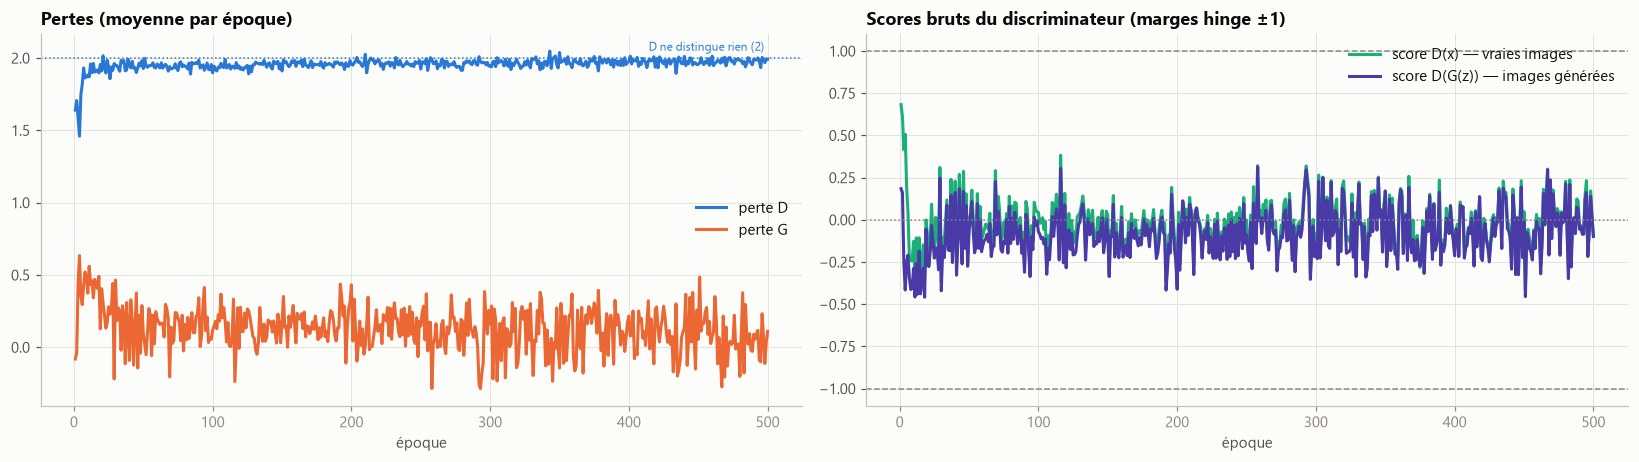

Temps moyen par époque : 1.75 s — 13 000 itérations au total


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
ax = axes[0]
ax.plot(hist["epoch"], hist["loss_d"], color=CAT[0], label="perte D")
ax.plot(hist["epoch"], hist["loss_g"], color=CAT[1], label="perte G")
if cfg.get("loss", "bce") == "hinge":
    # Hinge: D loss = 2 when D gives the same score (0) to real and fake → it tells nothing apart
    ax.axhline(2, color=CAT[0], ls=":", lw=1)
    ax.text(hist["epoch"].max(), 2.03, "D ne distingue rien (2) ", ha="right", va="bottom", fontsize=8, color=CAT[0])
else:
    ax.axhline(np.log(4), color=CAT[0], ls=":", lw=1); ax.axhline(np.log(2), color=CAT[1], ls=":", lw=1)
ax.set_title("Pertes (moyenne par époque)"); ax.set_xlabel("époque"); ax.legend()
ax = axes[1]
if cfg.get("loss", "bce") == "hinge":
    # Hinge loss: D outputs are raw scores; D aims at +1 for real and −1 for fake.
    ax.plot(hist["epoch"], hist["logit_real"], color=CAT[2], label="score D(x) — vraies images")
    ax.plot(hist["epoch"], hist["logit_fake"], color=CAT[6], label="score D(G(z)) — images générées")
    for v in (1, -1):
        ax.axhline(v, color=MUTED, ls="--", lw=1)
    ax.axhline(0, color=MUTED, ls=":", lw=1)
    ax.set_title("Scores bruts du discriminateur (marges hinge ±1)")
    ax.legend(loc="upper right")
else:
    ax.plot(hist["epoch"], hist["d_real"], color=CAT[2], label="D(x) — vraies images")
    ax.plot(hist["epoch"], hist["d_fake"], color=CAT[6], label="D(G(z)) — images générées")
    ax.axhline(0.5, color=MUTED, ls="--", lw=1); ax.text(hist["epoch"].max(), 0.52, "équilibre 0,5 ", ha="right", fontsize=9, color=MUTED)
    ax.set_ylim(0, 1); ax.set_title("Sorties du discriminateur")
    ax.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
ax.set_xlabel("époque")
plt.tight_layout()
save(fig, "01_dynamics")
plt.show()
print(f"Temps moyen par époque : {hist['seconds'].iloc[1:].mean():.2f} s — {hist['iters'].iloc[-1]:,} itérations au total".replace(",", " "))

**Observations — le discriminateur ne distingue plus rien**

- La **perte de D reste collée à 2** pendant tout l'entraînement. Avec la perte hinge, 2 est exactement la valeur
  obtenue quand D donne le **même score** aux vraies et aux fausses images.
- Les **scores bruts** le confirment : D(x) et D(G(z)) oscillent tous deux autour de 0, avec un écart moyen d'environ
  **0,05**, très loin des marges +1 / −1 que la perte hinge lui demande d'atteindre.
- C'est l'**exact opposé du modèle n°1** : là-bas le discriminateur était trop fort (D(x) → 0,98), ici il est
  **trop faible**. Deux freins s'additionnent — la normalisation spectrale, qui borne sa capacité de réaction, et
  DiffAugment, qui rend sa tâche plus difficile — alors que les hyperparamètres (ceux du DCGAN) n'ont pas été adaptés.
- **Aucune crise** en revanche : pas de pic, pas d'effondrement. L'objectif de stabilité est atteint… mais par excès.

## 3. Les métriques au fil de l'entraînement

Les lignes horizontales sont les **faux générateurs** du notebook 03 : elles situent le modèle sur l'échelle de lecture.

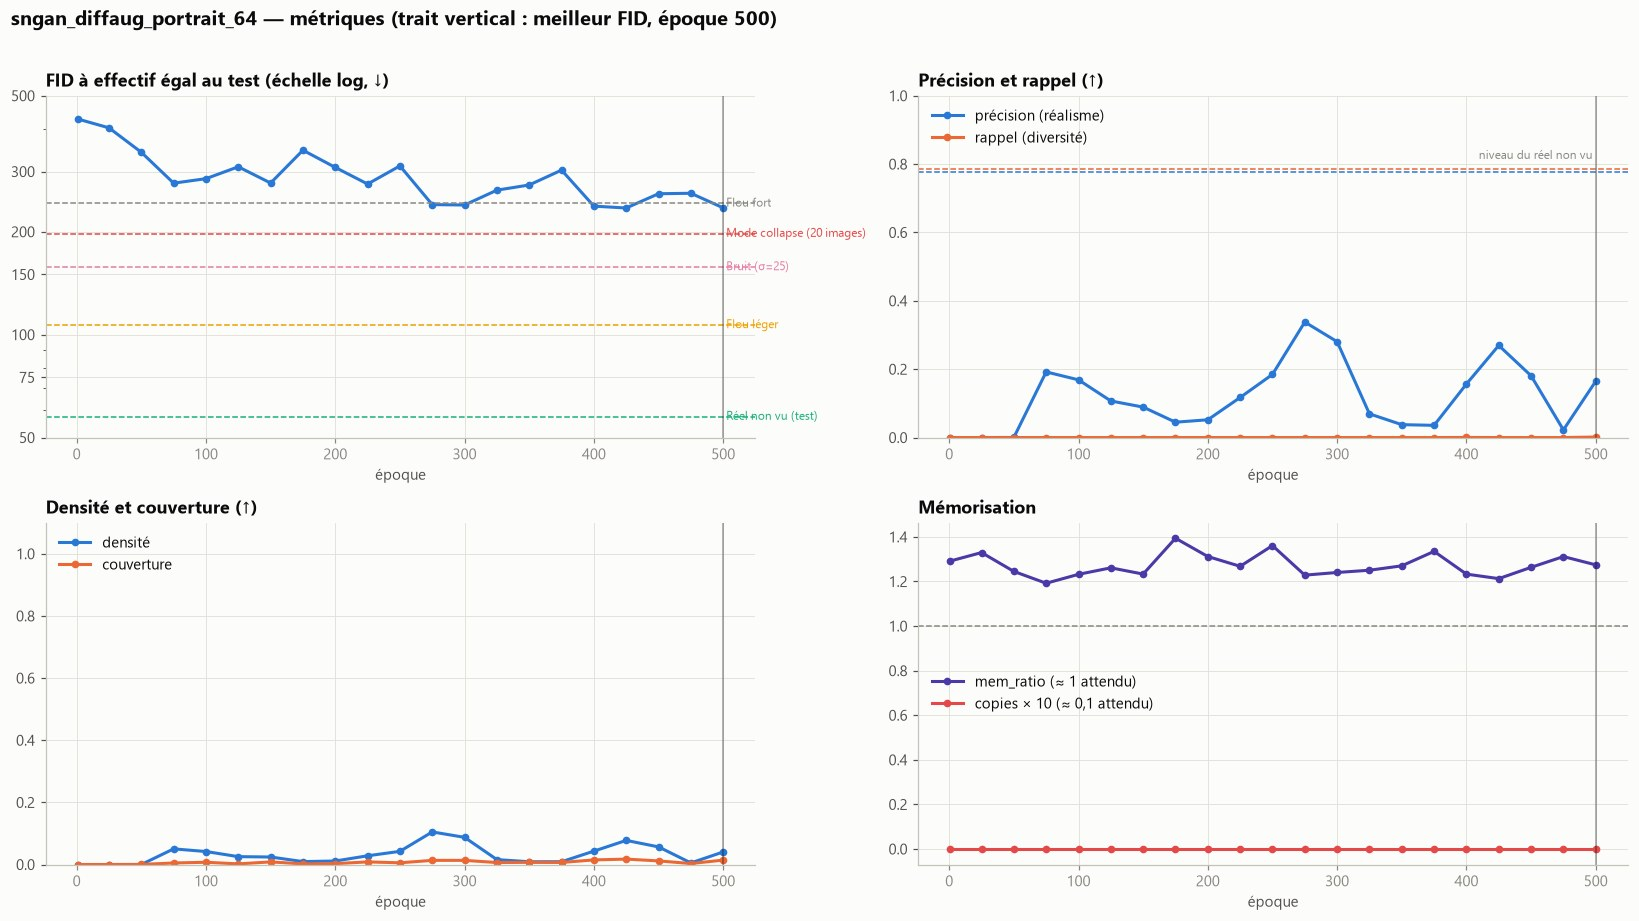

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
0,1,421.289,427.240,522.908,0.000,0.000,0.000,0.000,1.292,0.0
1,25,391.101,402.668,476.778,0.000,0.000,0.000,0.000,1.330,0.0
2,50,327.866,341.596,369.253,0.000,0.000,0.000,0.000,1.245,0.0
3,75,251.681,277.424,271.315,0.192,0.000,0.050,0.005,1.192,0.0
4,100,263.085,285.972,288.288,0.169,0.000,0.042,0.007,1.232,0.0
5,125,285.174,309.769,318.531,0.107,0.000,0.025,0.002,1.261,0.0
6,150,250.219,277.660,272.474,0.089,0.000,0.024,0.008,1.233,0.0
7,175,317.474,346.373,361.533,0.045,0.000,0.009,0.002,1.394,0.0
8,200,282.097,308.515,305.890,0.052,0.000,0.011,0.003,1.312,0.0
9,225,245.581,275.819,265.422,0.117,0.000,0.028,0.008,1.268,0.0


In [5]:
best = ev.loc[ev["FID"].idxmin()]
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))

ax = axes[0, 0]
ax.plot(ev["epoch"], ev["FID_ntest"], color=MAIN, marker="o", ms=4, label=RUN)
for lbl, c in [("Réel non vu (test)", CAT[2]), ("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4]),
               ("Mode collapse (20 images)", CAT[7]), ("Flou fort", MUTED)]:
    ax.axhline(bl.loc[lbl, "FID_ntest"], color=c, ls="--", lw=1)
    ax.text(ev["epoch"].max(), bl.loc[lbl, "FID_ntest"], f" {lbl}", va="center", fontsize=8, color=c)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(mtick.ScalarFormatter()); ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks([50, 75, 100, 150, 200, 300, 500])
ax.set_title("FID à effectif égal au test (échelle log, ↓)"); ax.set_xlabel("époque")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[0, 1]
ax.plot(ev["epoch"], ev["precision"], color=CAT[0], marker="o", ms=4, label="précision (réalisme)")
ax.plot(ev["epoch"], ev["recall"], color=CAT[1], marker="o", ms=4, label="rappel (diversité)")
ax.axhline(bl.loc["Réel non vu (test)", "precision"], color=CAT[0], ls="--", lw=1)
ax.axhline(bl.loc["Réel non vu (test)", "recall"], color=CAT[1], ls="--", lw=1)
ax.text(ev["epoch"].max(), bl.loc["Réel non vu (test)", "recall"] + 0.03, "niveau du réel non vu ", ha="right", fontsize=8, color=MUTED)
ax.set_ylim(0, 1); ax.set_title("Précision et rappel (↑)"); ax.set_xlabel("époque"); ax.legend(loc="upper left")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 0]
ax.plot(ev["epoch"], ev["density"], color=CAT[0], marker="o", ms=4, label="densité")
ax.plot(ev["epoch"], ev["coverage"], color=CAT[1], marker="o", ms=4, label="couverture")
ax.set_ylim(0, max(1.1, ev["density"].max() * 1.1)); ax.set_title("Densité et couverture (↑)"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 1]
ax.plot(ev["epoch"], ev["mem_ratio"], color=CAT[6], marker="o", ms=4, label="mem_ratio (≈ 1 attendu)")
ax.plot(ev["epoch"], ev["copies"] * 10, color=CAT[7], marker="o", ms=4, label="copies × 10 (≈ 0,1 attendu)")
ax.axhline(1, color=MUTED, ls="--", lw=1)
ax.set_title("Mémorisation"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)
fig.suptitle(f"{RUN} — métriques (trait vertical : meilleur FID, époque {int(best['epoch'])})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97))
save(fig, "02_metrics")
plt.show()

ev[["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]].round(3)

**Observations**

- Le FID baisse beaucoup plus lentement que pour les deux autres modèles et oscille entre 200 et 330 ; il atteint son
  meilleur niveau **à la dernière époque** (FID 198 ; 235 à effectif égal). Le modèle **progressait encore** : il est
  sous-entraîné, pas effondré.
- **Le rappel est resté à 0 pendant tout l'entraînement** : le générateur ne couvre quasiment aucune partie de la
  variété des portraits réels. La précision (≈ 0,17) et la couverture (0,01) sont les plus basses des trois modèles.
- Pas de mémorisation (`mem_ratio` 1,27).

## 4. Évolution visuelle à bruit fixe

Les grilles sont générées à chaque évaluation à partir des **mêmes vecteurs latents** : on voit chaque « tableau »
se former. On affiche ici les 16 premières images de chaque grille.

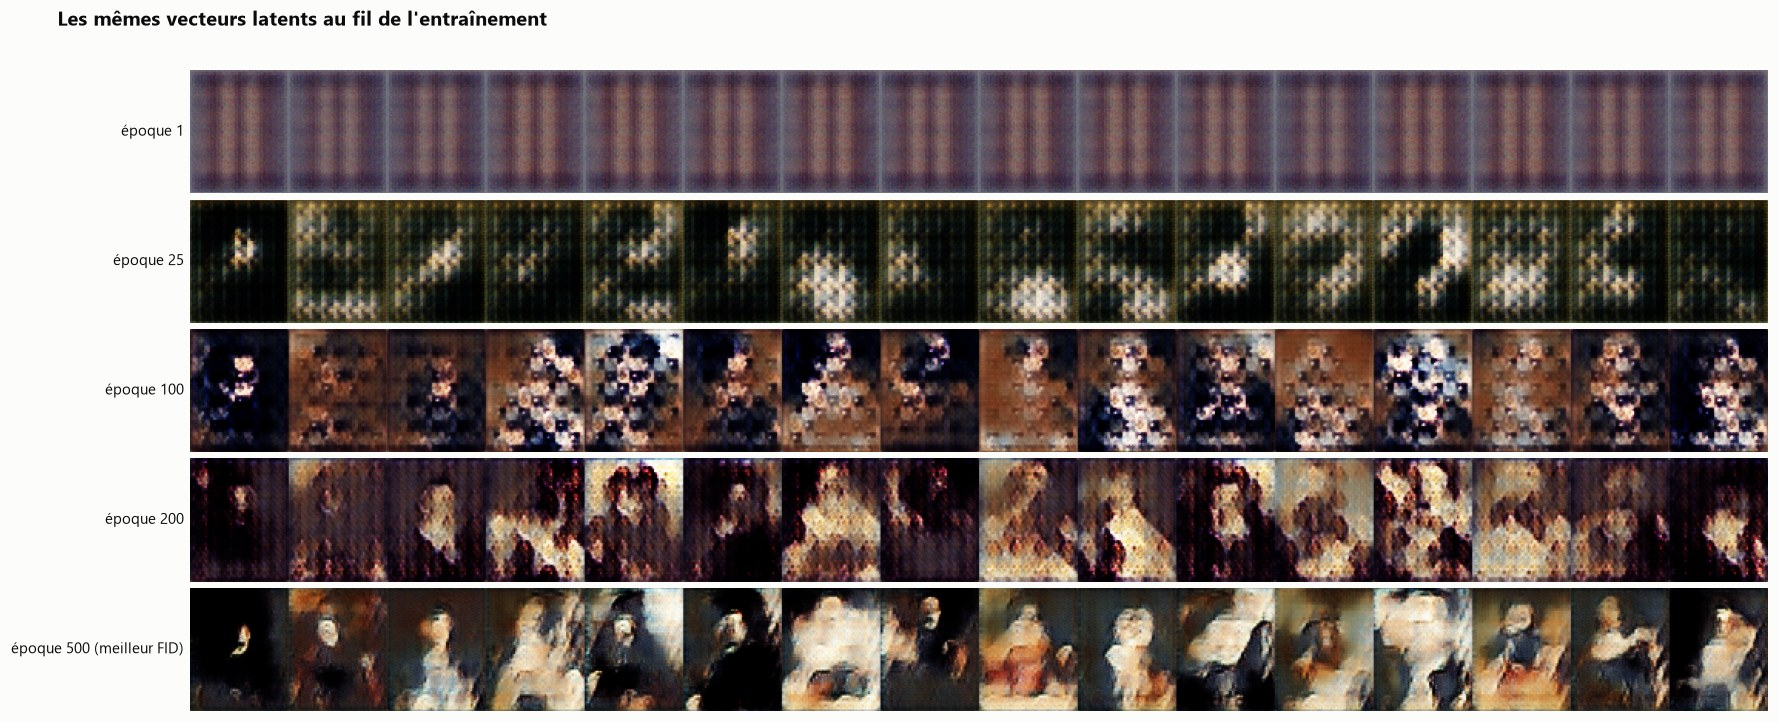

In [6]:
def grid_tiles(path, n=16, ncol=8):
    # Cut a grid saved by torchvision (2 px padding) into individual tiles.
    g = np.asarray(Image.open(path).convert("RGB"))
    w, h, p = SIZE[0], SIZE[1], 2
    return [g[p + (i // ncol) * (h + p): p + (i // ncol) * (h + p) + h, p + (i % ncol) * (w + p): p + (i % ncol) * (w + p) + w]
            for i in range(n)]


epochs_avail = sorted(int(p.stem.split("_")[1]) for p in (RUN_DIR / "samples").glob("epoch_*.png"))
show = sorted({epochs_avail[0], 25, 100, 200, int(best["epoch"]), epochs_avail[-1]} & set(epochs_avail))
fig, axes = plt.subplots(len(show), 1, figsize=(16, 1.25 * len(show) + 0.4))
for ax, e in zip(axes, show):
    tiles = grid_tiles(RUN_DIR / "samples" / f"epoch_{e:04d}.png")
    ax.imshow(np.concatenate(tiles, axis=1)); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    tag = " (meilleur FID)" if e == int(best["epoch"]) else ""
    ax.set_ylabel(f"époque {e}{tag}", rotation=0, ha="right", va="center", fontsize=10, color=INK)
fig.suptitle("Les mêmes vecteurs latents au fil de l'entraînement", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=0.4)
save(fig, "03_evolution")
plt.show()

**Observations** — l'évolution est lente et assez uniforme : des taches brun-orangé sans structure jusqu'à l'époque
~150, puis des silhouettes sombres qui s'affinent peu à peu. Aucune grille ne montre de mode collapse ou de motif
répété, contrairement au modèle n°2.

## 5. Le meilleur checkpoint

On recharge le générateur au meilleur FID et on compare ses images à de vraies peintures du train, à la même
résolution.

Checkpoint de l'époque 500 — FID 197.6


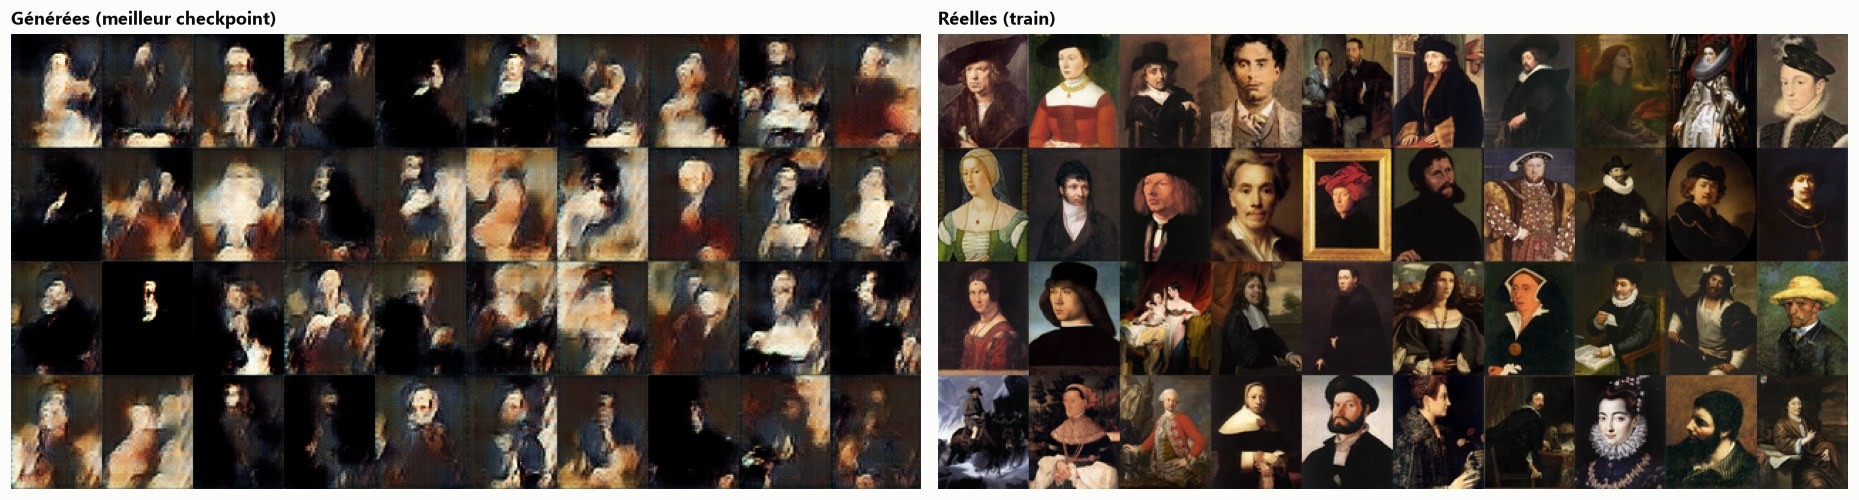

In [7]:
ckpt = torch.load(RUN_DIR / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"]).to(DEVICE)
G.load_state_dict(ckpt["G"])
print(f"Checkpoint de l'époque {ckpt['epoch']} — FID {ckpt['scores']['FID']:.1f}")

z = torch.randn(40, cfg["nz"], generator=torch.Generator().manual_seed(123)).to(DEVICE)
fake = tr.generate(G, z).permute(0, 2, 3, 1).cpu().numpy()
real = ds.load_split(cfg["genre"], "train", SIZE)
real = real[np.random.default_rng(123).choice(len(real), 40, replace=False)]


def mosaic(imgs, ncol=10):
    rows = [np.concatenate(imgs[i:i + ncol], axis=1) for i in range(0, len(imgs), ncol)]
    return np.concatenate(rows, axis=0)


fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))
for ax, imgs, title in [(axes[0], fake, "Générées (meilleur checkpoint)"), (axes[1], real, "Réelles (train)")]:
    ax.imshow(mosaic(list(imgs))); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "04_best_vs_real")
plt.show()

### 5.1 Contrôle visuel de la mémorisation

Pour quelques images générées, on cherche l'image du train la plus proche dans l'espace d'Inception. Si le générateur
recopiait, on retrouverait la même œuvre.

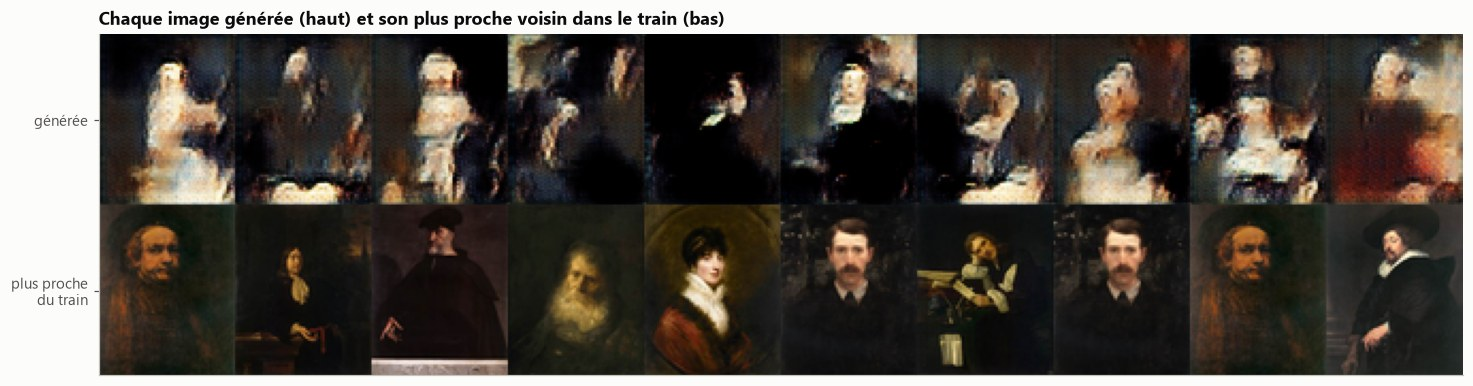

In [8]:
ref = mt.Reference.load_or_compute(cfg["genre"], SIZE, ds.DATASETS / cfg["genre"])
f_fake, _ = mt.extract_features(fake[:10])
d = torch.cdist(torch.from_numpy(f_fake).float(), torch.from_numpy(ref.train).float())
nn_idx = d.argmin(1).numpy()
train_all = ds.load_split(cfg["genre"], "train", SIZE)
fig, ax = plt.subplots(figsize=(16, 4.2))
top = np.concatenate(list(fake[:10]), axis=1)
bottom = np.concatenate([train_all[i] for i in nn_idx], axis=1)
ax.imshow(np.concatenate([top, bottom], axis=0)); ax.set_xticks([]); ax.set_yticks([SIZE[1] / 2, SIZE[1] * 1.5], ["générée", "plus proche\ndu train"])
ax.grid(False)
ax.set_title("Chaque image générée (haut) et son plus proche voisin dans le train (bas)")
save(fig, "05_nearest_neighbors")
plt.show()

### 5.2 Interpolation dans l'espace latent

Autre test de la veille (question 7) : on relie deux vecteurs latents et on génère les images intermédiaires. Des
transitions **progressives** indiquent que le générateur a appris un espace continu de « tableaux possibles » ; des
sauts brusques trahiraient un apprentissage par cœur de quelques images.

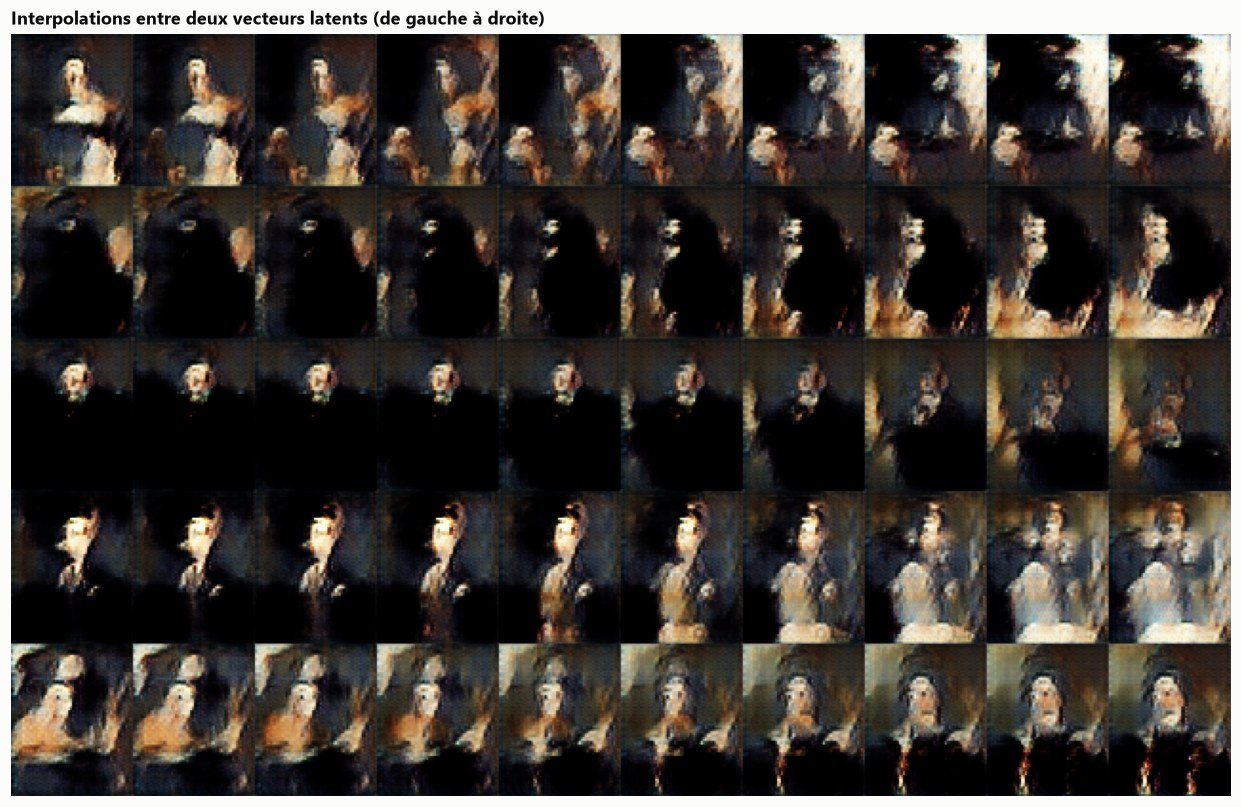

In [9]:
def slerp(a, b, t):
    # Spherical interpolation: stays at the "right distance" from the origin, like Gaussian vectors.
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


g = torch.Generator().manual_seed(7)
steps = torch.linspace(0, 1, 10)
rows = []
for _ in range(5):
    a, b = torch.randn(cfg["nz"], generator=g), torch.randn(cfg["nz"], generator=g)
    zs = torch.stack([slerp(a, b, t) for t in steps]).to(DEVICE)
    rows.append(np.concatenate(list(tr.generate(G, zs).permute(0, 2, 3, 1).cpu().numpy()), axis=1))
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(np.concatenate(rows, axis=0)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "06_interpolation")
plt.show()

**Observations** — les images restent au stade d'**ébauches** : silhouettes sombres, taches de lumière à la place du
visage, palette réduite (noir, brun, touches de bleu et de blanc). On reconnaît l'idée d'un portrait, rarement plus.
Pas de copie du train ; les interpolations sont continues mais changent peu, signe d'un générateur qui a appris une
distribution très étroite (cohérent avec le rappel nul).

## 6. Comparaison avec les modèles précédents

Tous les runs du même genre et de la même résolution sont retrouvés automatiquement dans `runs/`. Même données,
même protocole d'évaluation : les écarts viennent uniquement de ce qui a changé entre les modèles.

Runs comparés : ['dcgan_diffaug_portrait_64', 'dcgan_portrait_64', 'sngan_diffaug_portrait_64']


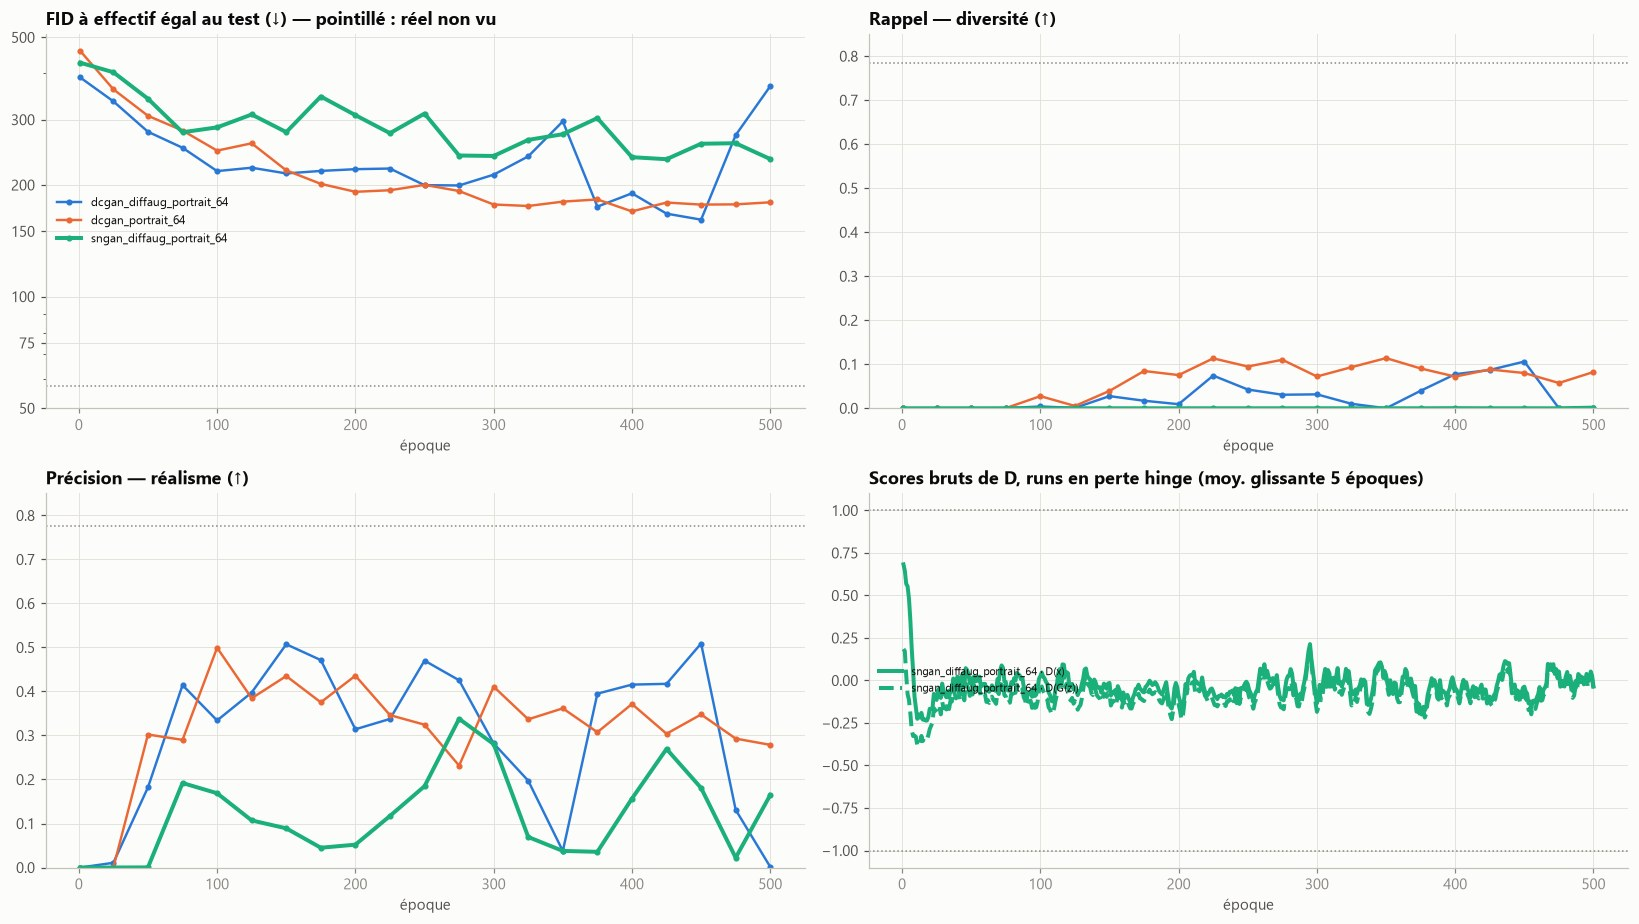

In [10]:
others, losses = [], {}
for p in sorted((ROOT / "runs").glob("*/config.json")):
    c = json.loads(p.read_text(encoding="utf-8"))
    if c["genre"] == cfg["genre"] and tuple(c["size"]) == SIZE and (p.parent / "eval.csv").exists():
        others.append((p.parent.name, pd.read_csv(p.parent / "eval.csv"), pd.read_csv(p.parent / "history.csv")))
        losses[p.parent.name] = c.get("loss", "bce")
print("Runs comparés :", [n for n, _, _ in others])
MY_LOSS = cfg.get("loss", "bce")

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
for k, (name, e, h) in enumerate(others):
    col, lw = CAT[k % len(CAT)], 2.6 if name == RUN else 1.6
    axes[0, 0].plot(e["epoch"], e["FID_ntest"], color=col, lw=lw, marker="o", ms=3, label=name)
    axes[0, 1].plot(e["epoch"], e["recall"], color=col, lw=lw, marker="o", ms=3, label=name)
    axes[1, 0].plot(e["epoch"], e["precision"], color=col, lw=lw, marker="o", ms=3, label=name)
    # D outputs are only comparable between runs with the same loss (probabilities in bce, scores in hinge)
    if losses[name] == MY_LOSS:
        kr, kf = ("logit_real", "logit_fake") if MY_LOSS == "hinge" else ("d_real", "d_fake")
        axes[1, 1].plot(h["epoch"], h[kr].rolling(5, min_periods=1).mean(), color=col, lw=lw, label=f"{name} · D(x)")
        axes[1, 1].plot(h["epoch"], h[kf].rolling(5, min_periods=1).mean(), color=col, lw=lw, ls="--", label=f"{name} · D(G(z))")
axes[0, 0].axhline(bl.loc["Réel non vu (test)", "FID_ntest"], color=MUTED, ls=":", lw=1)
axes[0, 0].set_yscale("log"); axes[0, 0].yaxis.set_major_formatter(mtick.ScalarFormatter())
axes[0, 0].yaxis.set_minor_formatter(mtick.NullFormatter()); axes[0, 0].set_yticks([50, 75, 100, 150, 200, 300, 500])
axes[0, 0].set_title("FID à effectif égal au test (↓) — pointillé : réel non vu")
axes[0, 1].axhline(bl.loc["Réel non vu (test)", "recall"], color=MUTED, ls=":", lw=1)
axes[0, 1].set_title("Rappel — diversité (↑)"); axes[0, 1].set_ylim(0, 0.85)
axes[1, 0].axhline(bl.loc["Réel non vu (test)", "precision"], color=MUTED, ls=":", lw=1)
axes[1, 0].set_title("Précision — réalisme (↑)"); axes[1, 0].set_ylim(0, 0.85)
if MY_LOSS == "hinge":
    for v in (1, -1):
        axes[1, 1].axhline(v, color=MUTED, ls=":", lw=1)
    axes[1, 1].set_title("Scores bruts de D, runs en perte hinge (moy. glissante 5 époques)")
else:
    axes[1, 1].axhline(0.5, color=MUTED, ls=":", lw=1); axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_title("Sorties de D, runs en perte BCE (moy. glissante 5 époques)")
for ax in axes.flat:
    ax.set_xlabel("époque")
axes[0, 0].legend(fontsize=8); axes[1, 1].legend(fontsize=7.5, loc="center left")
plt.tight_layout()
save(fig, "07_comparison")
plt.show()

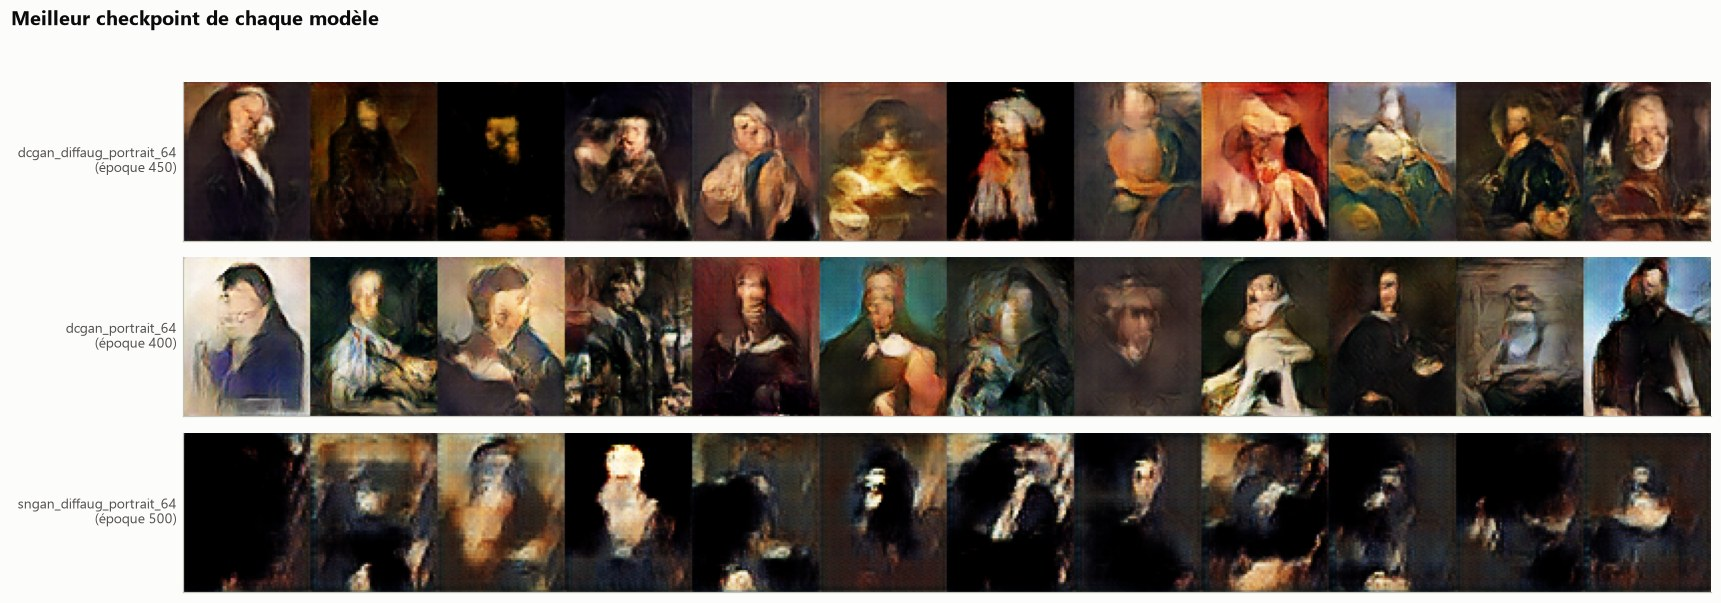

In [11]:
# Same latent vectors, best checkpoint of each model
z_cmp = torch.randn(12, cfg["nz"], generator=torch.Generator().manual_seed(2024)).to(DEVICE)
strips = []
for name, _, _ in others:
    ck = torch.load(ROOT / "runs" / name / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
    c = ck["config"]
    g = Generator(c["nz"], c["ngf"], base_grid(tuple(c["size"]), c["n_up"]), c["n_up"]).to(DEVICE)
    g.load_state_dict(ck["G"])
    strips.append((name, ck["epoch"], np.concatenate(list(tr.generate(g, z_cmp).permute(0, 2, 3, 1).cpu().numpy()), axis=1)))
fig, axes = plt.subplots(len(strips), 1, figsize=(16, 1.75 * len(strips) + 0.3), squeeze=False)
for ax, (name, ep, strip) in zip(axes[:, 0], strips):
    ax.imshow(strip); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_ylabel(f"{name}\n(époque {ep})", rotation=0, ha="right", va="center", fontsize=9)
fig.suptitle("Meilleur checkpoint de chaque modèle", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "08_comparison_samples")
plt.show()

**Observations**

- **Le modèle n°3 est le moins bon des trois sur toutes les métriques de qualité** : FID 198 contre 130 (n°1) et
  116 (n°2), rappel nul.
- **Mais c'est le seul sans aucune rechute** : son dernier checkpoint est aussi son meilleur, là où le modèle n°2
  finissait à FID 340.
- Les trois modèles dessinent une histoire cohérente autour de l'équilibre entre les deux réseaux (cf. veille,
  question 9) :

  | Modèle | Discriminateur | Conséquence |
  |---|---|---|
  | n°1 · DCGAN | **trop fort** (mémorise le train) | plateau, faible diversité |
  | n°2 · + DiffAugment | équilibré… puis instable | meilleur pic, mais effondrements |
  | n°3 · + normalisation spectrale | **trop faible** (ne distingue rien) | stable, mais apprentissage très lent |

## 7. Bilan chiffré

In [12]:
reg = pd.read_csv(ROOT / "reports" / "metrics" / "models.csv")
cols = ["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
# Every model of the same genre and resolution, then the reference fake generators
same = reg[(reg["genre"] == cfg["genre"]) & (reg["size"] == f"{SIZE[0]}x{SIZE[1]}")]
mine = same.set_index(same["run"] + " · " + same["checkpoint"])[cols]
refs = bl.loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Mode collapse (20 images)", "Flou fort"],
              [c for c in cols if c != "epoch"]]
refs.index = "réf. · " + refs.index
pd.concat([mine, refs]).round(3)

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
dcgan_portrait_64 · best,400.0,129.988,169.740,119.640,0.372,0.072,0.166,0.109,1.199,0.000
dcgan_portrait_64 · last,500.0,137.645,179.586,135.064,0.279,0.082,0.116,0.094,1.225,0.000
dcgan_diffaug_portrait_64 · best,450.0,116.392,161.252,100.441,0.509,0.106,0.304,0.201,1.182,0.000
dcgan_diffaug_portrait_64 · last,500.0,339.505,369.273,399.580,0.001,0.000,0.000,0.001,1.491,0.000
sngan_diffaug_portrait_64 · best,500.0,197.609,234.930,205.255,0.165,0.001,0.040,0.014,1.275,0.000
sngan_diffaug_portrait_64 · last,500.0,197.609,234.930,205.255,0.165,0.001,0.040,0.014,1.275,0.000
réf. · Réel non vu (test),NaN,57.562,57.562,-0.223,0.776,0.785,0.913,0.396,1.000,0.010
réf. · Flou léger,NaN,61.232,106.555,56.554,0.684,0.712,0.268,0.671,1.025,0.029
réf. · Bruit (σ=25),NaN,113.950,157.661,121.322,0.141,0.237,0.037,0.111,1.177,0.001
réf. · Mode collapse (20 images),NaN,196.333,197.167,15.759,1.000,0.006,0.999,0.029,0.001,1.000


## 8. Conclusion

| | n°1 · DCGAN | n°2 · + DiffAugment | n°3 · + SN + hinge |
|---|---|---|---|
| Meilleur FID (époque) | 130 (400) | **116** (450) | 198 (500) |
| FID à effectif égal | 170 | **161** | 235 |
| Précision / rappel | 0,37 / 0,07 | **0,51 / 0,11** | 0,17 / 0,00 |
| FID final (époque 500) | 138 | 340 | **198** |
| Stabilité | plateau | 2 effondrements | **aucune rechute** |

**L'hypothèse est à moitié validée.** La normalisation spectrale a bien supprimé l'instabilité — aucune crise, dernier
checkpoint = meilleur checkpoint — mais au prix d'un discriminateur **trop bridé** pour guider le générateur.

**Ce n'est pas un échec de la technique, mais des hyperparamètres.** Le SNGAN d'origine n'utilise pas les réglages du
DCGAN : il compense le bridage du discriminateur en l'entraînant **davantage** — plusieurs mises à jour de D par mise
à jour de G (5 dans l'article), ou un taux d'apprentissage de D plus élevé que celui de G (règle TTUR, Heusel et al.,
2017), et Adam avec β₁ = 0, β₂ = 0,9. Nous avons changé l'architecture et la perte en gardant tout le reste fixe :
c'était le bon protocole pour isoler l'effet, et il montre qu'**une technique n'a de sens qu'avec les
hyperparamètres qui lui correspondent**.

**Prochaine étape : l'optimisation des hyperparamètres avec Optuna.** C'est la réponse directe à ce constat. L'étude
portera sur les leviers qui règlent l'équilibre D/G — taux d'apprentissage de G et de D séparés, nombre de mises à
jour de D par itération, β₁ / β₂ d'Adam, normalisation spectrale oui/non, perte BCE ou hinge, politique DiffAugment —
avec un objectif robuste aux effondrements (moyenne des dernières évaluations plutôt que meilleur point).